# Risk dominance and successful collaboration

Visualizes successful collaboration rate against a game-theoretic risk-dominance measure, by arm, using `analysis/task_summary.csv` and `analysis/task_data.csv`.

**Per-task risk threshold `u`.** For a task, let design `A` be the collaborative option with the largest upside (see `analysis/README.md`). `u` is the normalized deviation loss -- the minimum belief that a partner will collaborate needed to make collaborating the better choice:

$$u = \frac{V_Y^{II} - V_A^{CI}}{(V_Y^{II} - V_A^{CI}) + (V_A^{CC} - V_Y^{IC})}$$

Design `A` is used as the reference because the experiment held the other collaborative designs (`B`, `C`) to a similar payoff structure, subject to rounding.

**Paired risk dominance `R`.** For a round, with `u_1`/`u_2` the two partners' task-level thresholds:

$$R = \tfrac{1}{2}\log\!\left(\frac{u_1}{1-u_1}\right) + \tfrac{1}{2}\log\!\left(\frac{u_2}{1-u_2}\right)$$

i.e. the average log-odds of the two partners' thresholds. Higher `R` means the individual (safe) strategy is more risk-dominant for that round's pairing of tasks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

task_summary = pd.read_csv("task_summary.csv")
task = pd.read_csv("task_data.csv")

## Compute `u` for each task

Restricted to the 30 real tasks (`task_difficulty`/`payoff_magnitude` not `n/a`) before computing `u` at all -- the 6 distraction tasks lack the collaborative-dilemma payoff structure the formula assumes (e.g. `Design Y` isn't a fixed 50/50 there), so `u` isn't just unused for them, it's not meaningful, and the formula produces nonsense (negative values, values >1, even a division by zero) if applied to them. `task_data.csv` already excludes distraction and training tasks entirely, so this restriction doesn't change anything downstream -- it just keeps invalid values out of the working data in the first place.

In [2]:
# task_summary.csv writes "n/a" for distraction/training tasks, but
# pandas' default read_csv treats that string as a missing-value marker
# and loads it as NaN -- so filter with notna(), not a string comparison.
task_summary = task_summary[task_summary["task_difficulty"].notna()].copy()

task_summary["u"] = (task_summary["V_Y_II"] - task_summary["V_A_CI"]) / (
    (task_summary["V_Y_II"] - task_summary["V_A_CI"]) + (task_summary["V_A_CC"] - task_summary["V_Y_IC"])
)

task_summary[["task_index", "task_difficulty", "payoff_magnitude", "u"]]

,task_index,task_difficulty,payoff_magnitude,u
0,0,1.0,5.0,0.550562
1,1,1.0,4.0,0.547170
2,2,1.0,3.0,0.549296
3,3,1.0,2.0,0.552000
4,4,1.0,1.0,0.541284
5,5,2.0,5.0,0.600000
6,6,2.0,4.0,0.604396
7,7,2.0,3.0,0.600000
8,8,2.0,2.0,0.602837
9,9,2.0,1.0,0.600000


`u` is nearly constant across `payoff_magnitude` within each `task_difficulty` tier (e.g. ~0.55 for tier 1, ~0.60 for tier 2, ...), confirming the reference-design assumption above: it behaves as a function of difficulty alone, up to rounding.

## Compute `R` for each round

Joins each round's `task_1`/`task_2` to their `u`, drops rounds with an undefined strategy (see `results/README.md#task_csv--decision-task-rounds`), classifies each round's outcome, and computes `R`.

In [3]:
missing = (task["strategy_1"] == "undefined") | (task["strategy_2"] == "undefined")
task = task[~missing].copy()


OUTCOME_ORDER = ["successful collaboration", "mutual independence", "coordination failure"]


def classify_outcome(row):
    s1, s2 = row["strategy_1"], row["strategy_2"]
    if s1 == "C" and s2 == "C":
        return "successful collaboration"
    if s1 == "I" and s2 == "I":
        return "mutual independence"
    return "coordination failure"


task["outcome"] = task.apply(classify_outcome, axis=1)
for outcome in OUTCOME_ORDER:
    task[outcome.replace(" ", "_")] = (task["outcome"] == outcome).astype(int)

u_by_index = task_summary.set_index("task_index")["u"]

# task_1/task_2 should only ever reference real tasks (0-29), all of which
# now have a u value after restricting task_summary above
assert task["task_1"].isin(u_by_index.index).all()
assert task["task_2"].isin(u_by_index.index).all()


def logit(p):
    return np.log(p / (1 - p))


u_1 = task["task_1"].map(u_by_index)
u_2 = task["task_2"].map(u_by_index)
task["R"] = 0.5 * logit(u_1) + 0.5 * logit(u_2)

task["R"].describe()

count    778.000000
mean       0.937895
std        0.341421
min        0.306528
25%        0.632063
50%        0.967988
75%        1.253855
max        1.558298
Name: R, dtype: float64

## Aggregate and plot

`R` takes 15 nearly-distinct raw values -- since `u` is effectively a function of `task_difficulty` alone, `R` is mostly determined by the unordered pair of difficulty tiers involved (6 tiers -> up to 21 combinations, 15 of which occur). But `u` varies slightly *within* a tier depending on `payoff_magnitude` (rounding in the underlying payoffs), so a few of those 15 values sit close enough together (e.g. 0.632 and 0.635) that they're really the same signal blurred by that rounding noise, not a meaningfully different `R`.

To average over that noise, `R` is grouped into 10 equal-width bins spanning its observed range, and each bin's mean successful-collaboration rate is plotted at that bin's actual mean `R` (not the bin edge/center). Variation is shown as a 95% CI on each point (normal approximation to the binomial, `1.96 * sqrt(p(1-p)/n)`) -- note this treats each round as independent, which (per `outcome_analysis.ipynb`) understates true uncertainty since rounds within a pair aren't independent; treat these bands as a rough sense of spread, not a rigorous interval.

In [4]:
N_BINS = 10
task["R_bin"] = pd.cut(task["R"], bins=N_BINS)

rows = []
for outcome in OUTCOME_ORDER:
    col = outcome.replace(" ", "_")
    g = task.groupby(["arm", "R_bin"], observed=True).agg(
        R_mean=("R", "mean"), rate=(col, "mean"), n=(col, "count"),
    ).reset_index()
    g["outcome"] = outcome
    rows.append(g)

agg = pd.concat(rows, ignore_index=True)
agg["se"] = np.sqrt(agg["rate"] * (1 - agg["rate"]) / agg["n"])
agg["ci95"] = 1.96 * agg["se"]

agg[agg["outcome"] == "successful collaboration"].drop(columns="outcome")

,arm,R_bin,R_mean,rate,n,se,ci95
0,control,"(0.305, 0.432]",0.306528,0.958333,24,0.040789,0.079947
1,control,"(0.432, 0.557]",0.541432,0.875000,24,0.067508,0.132315
2,control,"(0.557, 0.682]",0.632884,0.722222,72,0.052786,0.103460
3,control,"(0.682, 0.807]",0.792060,0.541667,24,0.101707,0.199346
4,control,"(0.807, 0.932]",0.899340,0.583333,24,0.100635,0.197244
5,control,"(0.932, 1.058]",0.999627,0.486111,72,0.058903,0.115450
6,control,"(1.058, 1.183]",1.125646,0.625000,24,0.098821,0.193690
7,control,"(1.183, 1.308]",1.272797,0.617021,47,0.070907,0.138978
8,control,"(1.308, 1.433]",1.420791,0.500000,24,0.102062,0.200042
9,control,"(1.433, 1.558]",1.558298,0.565217,23,0.103367,0.202598


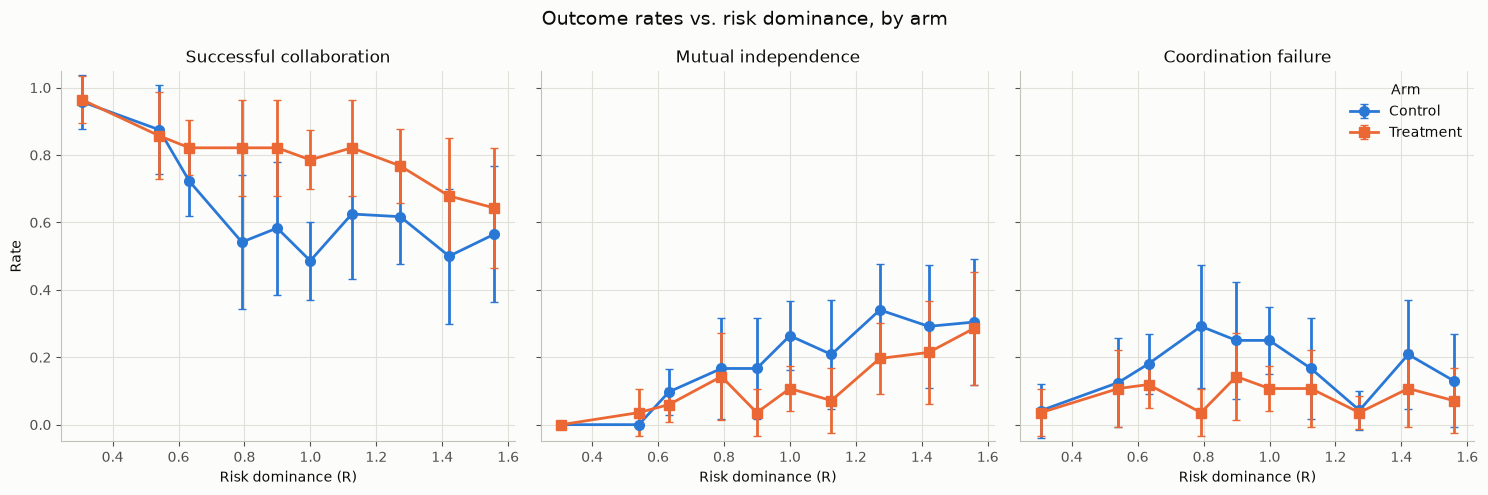

In [5]:
CHART_SURFACE = "#fcfcfb"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
SERIES = {"control": "#2a78d6", "treatment": "#eb6834"}
MARKERS = {"control": "o", "treatment": "s"}
TITLES = {
    "successful collaboration": "Successful collaboration",
    "mutual independence": "Mutual independence",
    "coordination failure": "Coordination failure",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=CHART_SURFACE, sharey=True)

for ax, outcome in zip(axes, OUTCOME_ORDER):
    ax.set_facecolor(CHART_SURFACE)
    for arm in ["control", "treatment"]:
        sub = agg[(agg["outcome"] == outcome) & (agg["arm"] == arm)].sort_values("R_mean")
        ax.errorbar(
            sub["R_mean"], sub["rate"], yerr=sub["ci95"],
            color=SERIES[arm], marker=MARKERS[arm], markersize=7,
            linewidth=2, capsize=3, label=arm.capitalize(),
        )
    ax.set_title(TITLES[outcome], color=PRIMARY_INK, fontsize=12)
    ax.set_xlabel("Risk dominance (R)", color=PRIMARY_INK)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=SECONDARY_INK)

axes[0].set_ylabel("Rate", color=PRIMARY_INK)
legend = axes[-1].legend(title="Arm", frameon=False, labelcolor=PRIMARY_INK, loc="upper right")
legend.get_title().set_color(PRIMARY_INK)

fig.suptitle("Outcome rates vs. risk dominance, by arm", color=PRIMARY_INK, fontsize=14)
fig.tight_layout()
plt.show()

## Interpretation

All three panels show the direction risk-dominance theory predicts: as `R` rises (individual play becomes more risk-dominant), successful collaboration falls while mutual independence rises, in both arms. Coordination failure is noisier and doesn't show as clean a trend in either arm.

Control's successful-collaboration rate declines more steeply than treatment's, which stays comparatively high and flat across most of the `R` range -- visually consistent with the `arm:diff_difficulty` interaction found in `outcome_analysis.ipynb`: the treatment appears to buffer against exactly the conditions (here, higher risk dominance) that erode collaboration in control. The mutual-independence panel tells the complementary story -- control's rate climbs higher than treatment's as `R` increases, meaning control's lost collaboration mostly becomes mutual independence rather than coordination failure.